# Entrenamiento del modelo de seguridad

Este notebook entrena un clasificador tradicional (no LLM) para detectar vulnerabilidades en codigo Java. Usa un dataset publico (OWASP Benchmark o Juliet) convertido a CSV con columnas `code` y `label`.

## 1. Carga y exploracion de datos

Carga el dataset y revisa columnas, tipos y estadisticas basicas.

In [1]:
import pandas as pd

# Ruta al CSV (ajusta si es necesario)
DATASET_PATH = "../data/dataset.csv"

df = pd.read_csv(DATASET_PATH)
print(df.head())
print(df.dtypes)
print(df.describe(include="all"))

                                                code  label
0  /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...      1
1  /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...      1
2  /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...      1
3  /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...      1
4  /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...      1
code     object
label     int64
dtype: object
                                                     code        label
count                                                2740  2740.000000
unique                                               2740          NaN
top     /**\n * OWASP Benchmark v1.2\n *\n * <p>This f...          NaN
freq                                                    1          NaN
mean                                                  NaN     0.516423
std                                                   NaN     0.499821
min                                                   NaN     0.000000
25%                       

## 2. Limpieza y preparacion

Gestiona nulos, duplicados y conversiones de tipos.

In [2]:
# Elimina duplicados
before = len(df)
df = df.drop_duplicates()
print(f"Duplicados removidos: {before - len(df)}")

# Manejo de nulos
df["code"] = df["code"].fillna("")
df["label"] = df["label"].fillna(0).astype(int)

# Verificacion final
print(df.isna().sum())

Duplicados removidos: 0
code     0
label    0
dtype: int64


## 3. Analisis exploratorio con visualizaciones

Distribuciones y deteccion de outliers.

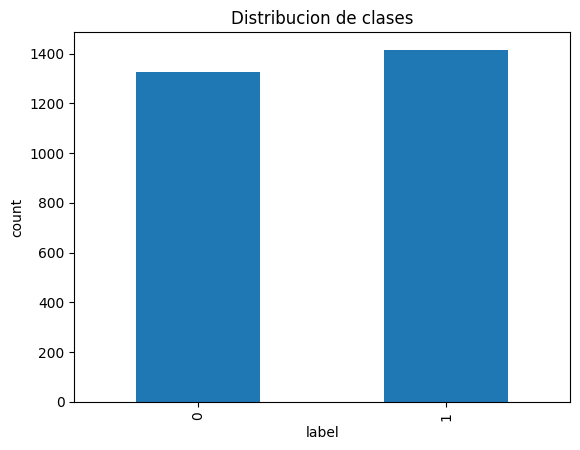

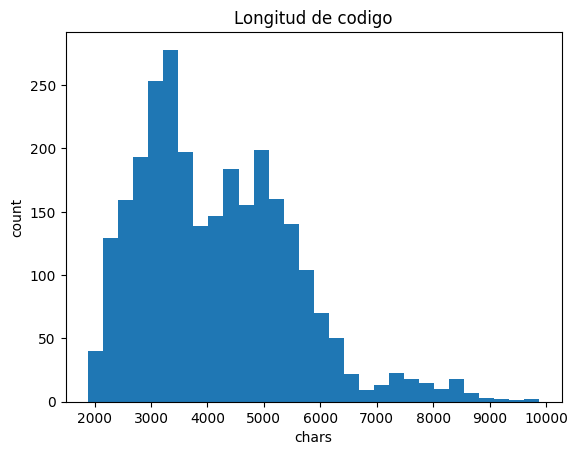

In [3]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts().sort_index()
label_counts.plot(kind="bar", title="Distribucion de clases")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

code_lengths = df["code"].astype(str).str.len()
plt.hist(code_lengths, bins=30)
plt.title("Longitud de codigo")
plt.xlabel("chars")
plt.ylabel("count")
plt.show()

## 4. Ingenieria de caracteristicas

Usamos el mismo extractor del pipeline para mantener consistencia.

In [12]:
import os
import sys
from pathlib import Path

import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer

repo_root = Path.cwd().parent
sys.path.append(str(repo_root / "scripts"))

# Desactiva AST para acelerar la extraccion (reactiva luego si quieres mas precision)
os.environ["DISABLE_AST"] = "1"

from feature_extraction import extract_features

# Limita el volumen para que no tarde demasiado (ajusta si quieres mas)
MAX_SAMPLES = 2000
if len(df) > MAX_SAMPLES:
    per_label = max(2, MAX_SAMPLES // max(1, df["label"].nunique()))
    df_sample = (
        df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), per_label), random_state=42))
        .sample(frac=1.0, random_state=42)
        .reset_index(drop=True)
    )
else:
    df_sample = df

codes_sample = df_sample["code"].astype(str).tolist()

feature_rows = []
for i, code in enumerate(codes_sample, start=1):
    feature_rows.append(extract_features(code))
    if i % 200 == 0:
        print(f"Procesados: {i}/{len(df_sample)}")

feature_names = list(feature_rows[0].keys())
numeric = np.array([[row[k] for k in feature_names] for row in feature_rows], dtype=float)

tfidf = TfidfVectorizer(
    token_pattern=r"[A-Za-z_][A-Za-z0-9_]*",
    ngram_range=(1, 2),
    min_df=2,
    max_features=8000,
)
X_text = tfidf.fit_transform(codes_sample)
X_num = csr_matrix(numeric)
X = hstack([X_text, X_num], format="csr")

y = df_sample["label"].astype(int).tolist()
print("Features numericas:", feature_names)

C:\Users\User\AppData\Local\Temp\ipykernel_20752\3496961628.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), per_label), random_state=42))


Procesados: 200/2000
Procesados: 400/2000
Procesados: 600/2000
Procesados: 800/2000
Procesados: 1000/2000
Procesados: 1200/2000
Procesados: 1400/2000
Procesados: 1600/2000
Procesados: 1800/2000
Procesados: 2000/2000
Features numericas: ['token_count', 'unique_token_count', 'avg_token_length', 'ast_max_depth', 'dangerous_total', 'sanitization_count', 'dangerous_to_sanitization', 'command_injection_hits', 'sql_injection_hits', 'deserialization_hits']


## 5. Entrenamiento de modelo

Entrena un modelo base con hiperparametros razonables.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## 6. Evaluacion y validacion

Metricas, matriz de confusion y validacion cruzada.

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

preds = model.predict(X_test)
print("Accuracy test:", accuracy_score(y_test, preds))
print("Matriz de confusion:\n", confusion_matrix(y_test, preds))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("Accuracy CV mean:", np.mean(cv_scores))

Accuracy test: 0.63
Matriz de confusion:
 [[126  74]
 [ 74 126]]
Accuracy CV mean: 0.588


## 7. Interpretacion del modelo

Revisa importancias de variables.

In [ ]:
import numpy as np
import pandas as pd

text_names = tfidf.get_feature_names_out().tolist()
all_names = text_names + feature_names

coefs = model.coef_.ravel()
coef_series = pd.Series(coefs, index=all_names)

print("Top positivos:")
print(coef_series.sort_values(ascending=False).head(10))
print("\nTop negativos:")
print(coef_series.sort_values(ascending=True).head(10))

## 8. Exportacion de resultados

Guarda el modelo entrenado y predicciones de ejemplo.

In [ ]:
import joblib
from pathlib import Path

out_path = Path(repo_root) / "ml" / "model.joblib"
joblib.dump({"model": model, "feature_names": feature_names, "vectorizer": tfidf}, out_path)
print("Modelo guardado en:", out_path)

predictions = model.predict(X_test)
pd.DataFrame({"pred": predictions, "true": y_test}).to_csv("predictions.csv", index=False)
print("Predicciones exportadas a predictions.csv")